# Notebook 4 — Analysis & Results
**Project:** Evaluating Robustness of Lightweight Object Detection Models Against Adversarial Noise  
**Step:** Load evaluation CSV → generate all charts, tables, and hypothesis validation for the final paper.

In [3]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [4]:
# ── 1. Paths ──────────────────────────────────────────────────────────────────
RESULTS_DIR = r'D:\Lightweight_Object_Detection_Robustness\results'
FIG_DIR     = RESULTS_DIR + r'\figures'
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(RESULTS_DIR + r'\evaluation_results.csv')
print(f'Loaded {len(df)} rows')
df.head()

Loaded 26 rows


,model,noise,severity,tp,fp,fn,precision,recall,f1,f1_person,f1_bicycle,f1_car,f1_motorcycle,f1_bus,f1_truck,f1_traffic_light,f1_stop_sign,clean_f1,rpd
0,yolov8n,clean,0,8044,1859,6991,0.8123,0.5350,0.6451,0.6870,0.4893,0.5195,0.6318,0.7075,0.4303,0.3801,0.6765,0.6451,0.0000
1,yolov8n,gaussian,1,7566,1601,7469,0.8254,0.5032,0.6252,0.6684,0.4718,0.4923,0.6041,0.6862,0.4050,0.3695,0.6667,0.6451,0.0308
2,yolov8n,gaussian,3,5590,1255,9445,0.8167,0.3718,0.5110,0.5691,0.3281,0.3205,0.4306,0.3989,0.2768,0.2246,0.5920,0.6451,0.2079
3,yolov8n,gaussian,5,2954,727,12081,0.8025,0.1965,0.3157,0.3822,0.1299,0.0827,0.0769,0.0070,0.1148,0.0691,0.5405,0.6451,0.5106
4,yolov8n,motion_blur,1,7000,1655,8035,0.8088,0.4656,0.5910,0.6370,0.3774,0.4624,0.5347,0.6587,0.3370,0.3046,0.6441,0.6451,0.0839


In [5]:
# ── 2. Constants ──────────────────────────────────────────────────────────────
NOISE_LABELS = {
    'gaussian'   : 'Gaussian Noise',
    'motion_blur': 'Motion Blur',
    'fog'        : 'Fog',
    'rain'       : 'Rain Streaks'
}
NOISE_ORDER  = ['gaussian', 'motion_blur', 'fog', 'rain']
SEVERITIES   = [1, 3, 5]
COLORS       = {'yolov8n': '#1F3864', 'yolov5n': '#ED7D31'}
NOISE_COLORS = {'gaussian':'#4472C4', 'motion_blur':'#FF0000',
                'fog':'#70AD47',      'rain':'#7030A0'}

CLEAN BASELINE
  Model   TP   FP   FN  Precision  Recall     F1
yolov8n 8044 1859 6991     0.8123  0.5350 0.6451
yolov5n 8485 2622 6550     0.7639  0.5643 0.6491


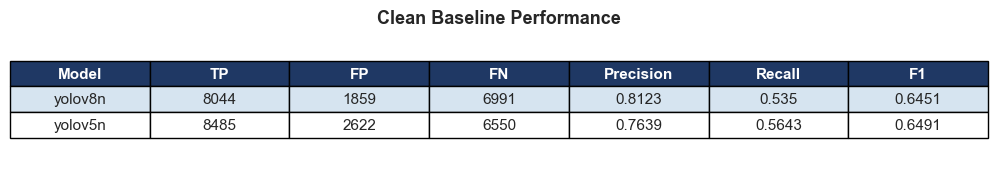

In [6]:
# ── 3. Clean Baseline Table ───────────────────────────────────────────────────
clean = df[df['noise'] == 'clean'][['model','tp','fp','fn','precision','recall','f1']].reset_index(drop=True)
clean.columns = ['Model','TP','FP','FN','Precision','Recall','F1']

print('CLEAN BASELINE')
print(clean.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 1.8))
ax.axis('off')
tbl = ax.table(cellText=clean.values, colLabels=clean.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1F3864')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 1:
        cell.set_facecolor('#D6E4F0')
ax.set_title('Clean Baseline Performance', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR + r'\table_clean_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

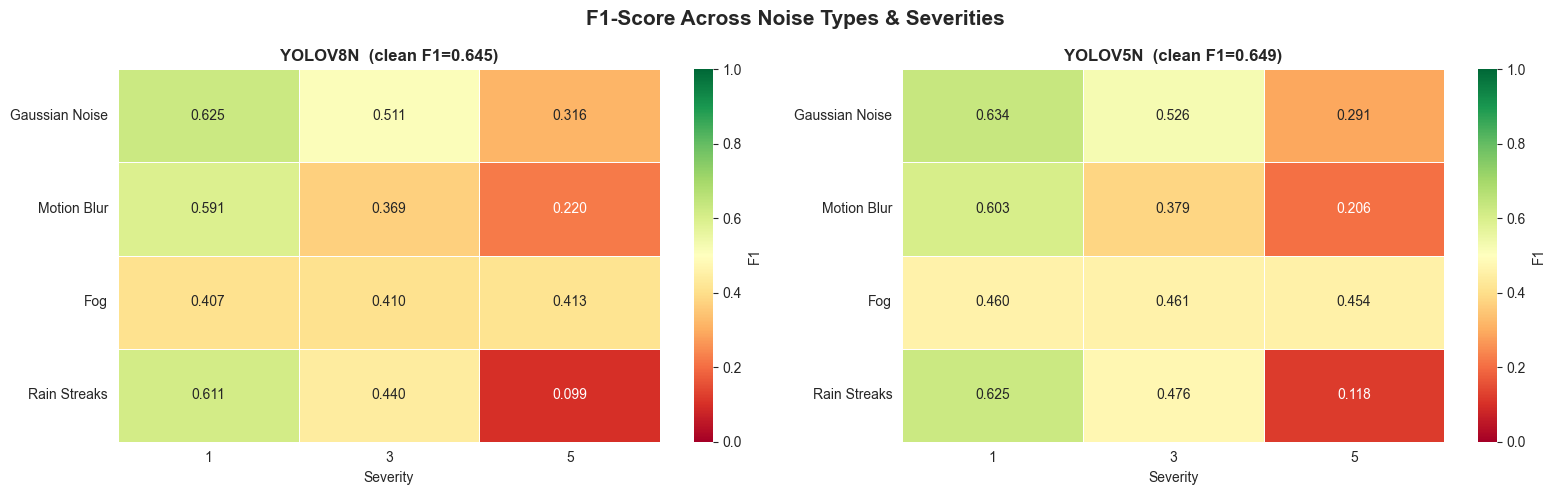

In [7]:
# ── 4. F1 Heatmap ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('F1-Score Across Noise Types & Severities', fontsize=15, fontweight='bold')

for ax, model_name in zip(axes, ['yolov8n', 'yolov5n']):
    sub   = df[(df['model'] == model_name) & (df['noise'].isin(NOISE_ORDER))]
    pivot = sub.pivot(index='noise', columns='severity', values='f1').reindex(NOISE_ORDER)
    pivot.index = [NOISE_LABELS[n] for n in NOISE_ORDER]

    clean_f1 = df[(df['model'] == model_name) & (df['noise'] == 'clean')]['f1'].values[0]
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.0, vmax=1.0, linewidths=0.5, cbar_kws={'label': 'F1'})
    ax.set_title(f'{model_name.upper()}  (clean F1={clean_f1:.3f})', fontweight='bold')
    ax.set_xlabel('Severity')
    ax.set_ylabel('')
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR + r'\fig1_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

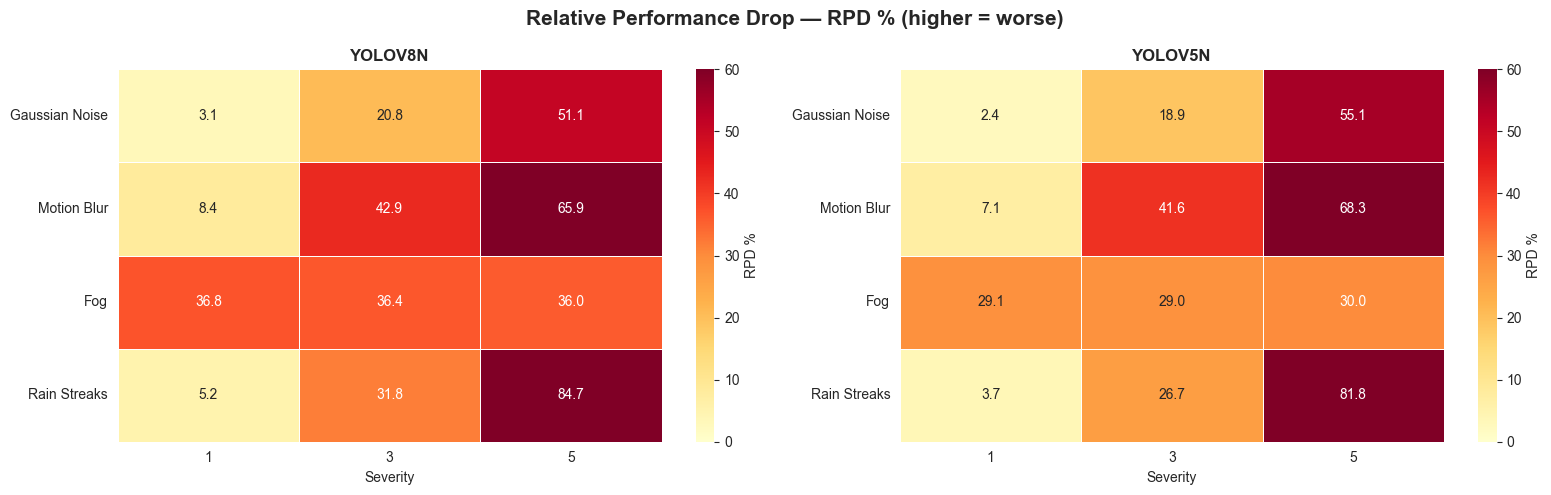

In [8]:
# ── 5. RPD Heatmap ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Relative Performance Drop — RPD % (higher = worse)', fontsize=15, fontweight='bold')

for ax, model_name in zip(axes, ['yolov8n', 'yolov5n']):
    sub   = df[(df['model'] == model_name) & (df['noise'].isin(NOISE_ORDER))]
    pivot = (sub.pivot(index='noise', columns='severity', values='rpd') * 100).reindex(NOISE_ORDER)
    pivot.index = [NOISE_LABELS[n] for n in NOISE_ORDER]

    sns.heatmap(pivot, ax=ax, annot=True, fmt='.1f', cmap='YlOrRd',
                vmin=0, vmax=60, linewidths=0.5, cbar_kws={'label': 'RPD %'})
    ax.set_title(model_name.upper(), fontweight='bold')
    ax.set_xlabel('Severity')
    ax.set_ylabel('')
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR + r'\fig2_rpd_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

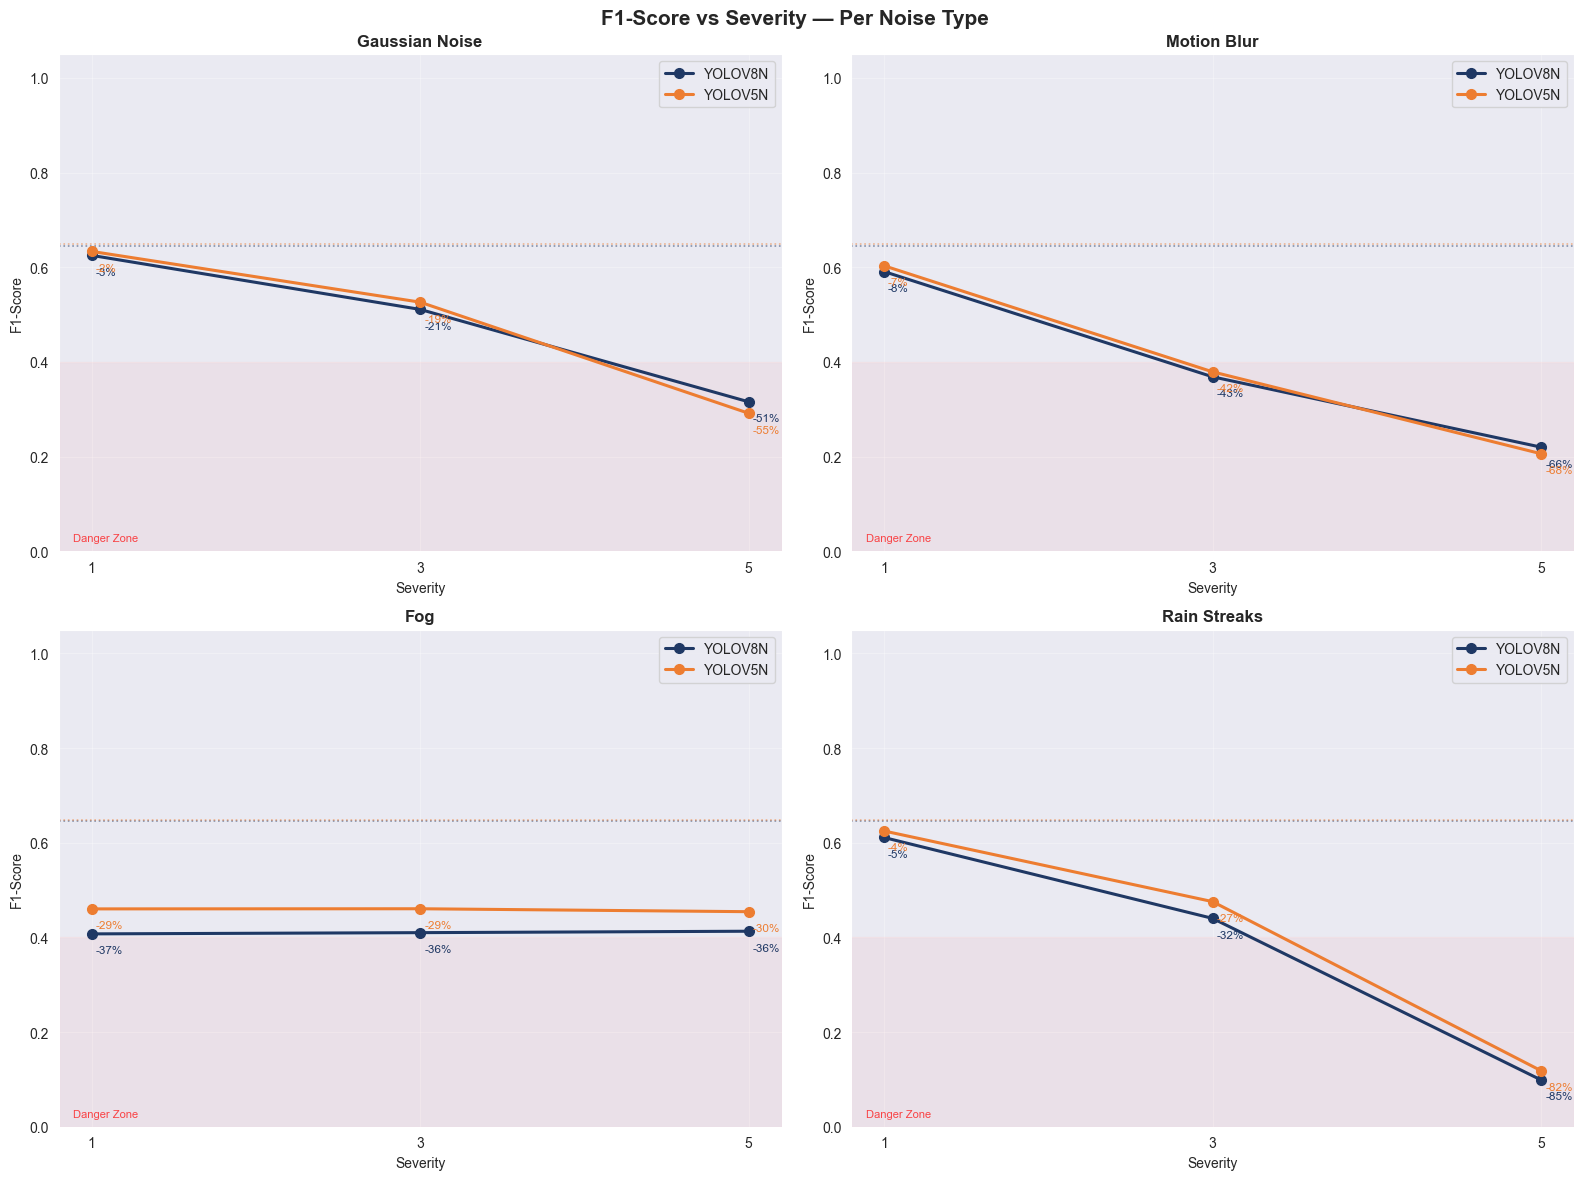

In [9]:
# ── 6. Severity Line Plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('F1-Score vs Severity — Per Noise Type', fontsize=15, fontweight='bold')

for ax, noise_key in zip(axes.flatten(), NOISE_ORDER):
    for model_name in ['yolov8n', 'yolov5n']:
        clean_f1 = df[(df['model'] == model_name) & (df['noise'] == 'clean')]['f1'].values[0]
        sub      = df[(df['model'] == model_name) & (df['noise'] == noise_key)].sort_values('severity')

        ax.axhline(y=clean_f1, color=COLORS[model_name], linestyle=':', linewidth=1.2, alpha=0.5)
        ax.plot(sub['severity'], sub['f1'], marker='o', linewidth=2.2, markersize=7,
                color=COLORS[model_name], label=model_name.upper())

        for _, row in sub.iterrows():
            ax.annotate(f"-{row['rpd']*100:.0f}%",
                        xy=(row['severity'], row['f1']),
                        xytext=(3, -14), textcoords='offset points',
                        fontsize=8.5, color=COLORS[model_name])

    ax.set_title(NOISE_LABELS[noise_key], fontweight='bold')
    ax.set_xlabel('Severity')
    ax.set_ylabel('F1-Score')
    ax.set_xticks([1, 3, 5])
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhspan(0, 0.4, alpha=0.04, color='red')
    ax.text(0.02, 0.02, 'Danger Zone', transform=ax.transAxes, fontsize=8, color='red', alpha=0.7)

plt.tight_layout()
plt.savefig(FIG_DIR + r'\fig3_severity_lines.png', dpi=150, bbox_inches='tight')
plt.show()

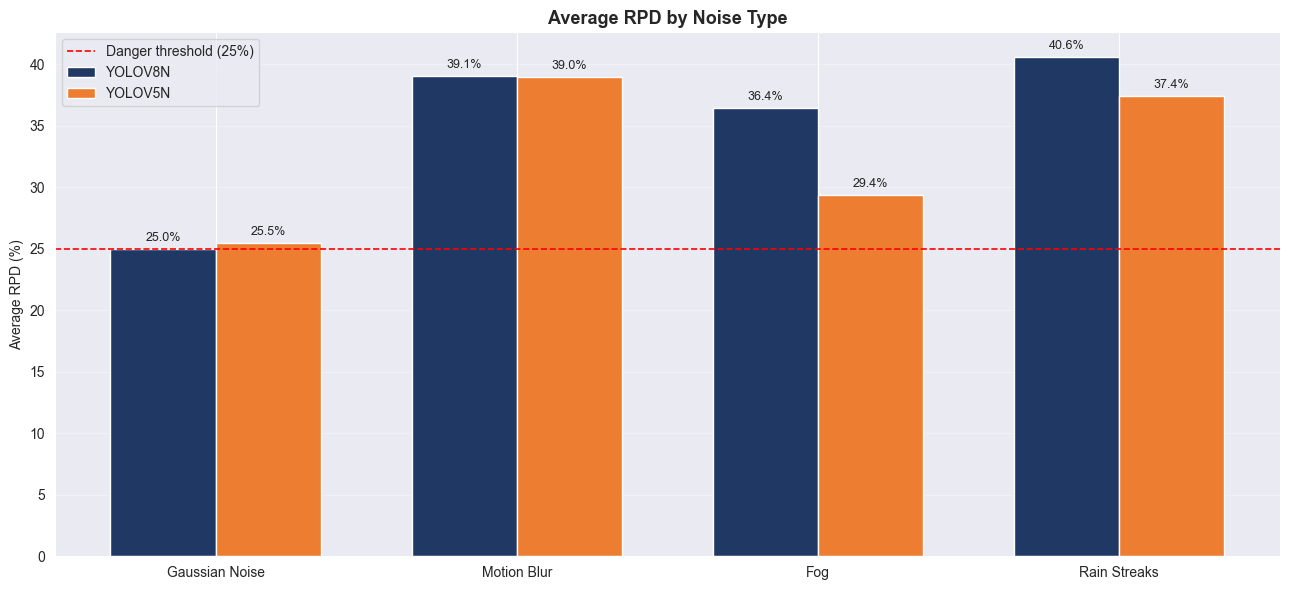

In [10]:
# ── 7. Average RPD Bar Chart ──────────────────────────────────────────────────
noisy   = df[df['noise'].isin(NOISE_ORDER)].copy()
avg_rpd = noisy.groupby(['model','noise'])['rpd'].mean().reset_index()
avg_rpd['rpd_pct'] = avg_rpd['rpd'] * 100

x     = np.arange(len(NOISE_ORDER))
width = 0.35
labels = [NOISE_LABELS[n] for n in NOISE_ORDER]

fig, ax = plt.subplots(figsize=(13, 6))
for i, model_name in enumerate(['yolov8n', 'yolov5n']):
    vals = [avg_rpd.loc[(avg_rpd['model']==model_name) &
                         (avg_rpd['noise']==n), 'rpd_pct'].values[0] for n in NOISE_ORDER]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=model_name.upper(),
                  color=COLORS[model_name], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.axhline(y=25, color='red', linestyle='--', linewidth=1.2, label='Danger threshold (25%)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Average RPD by Noise Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Average RPD (%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR + r'\fig4_avg_rpd_bars.png', dpi=150, bbox_inches='tight')
plt.show()

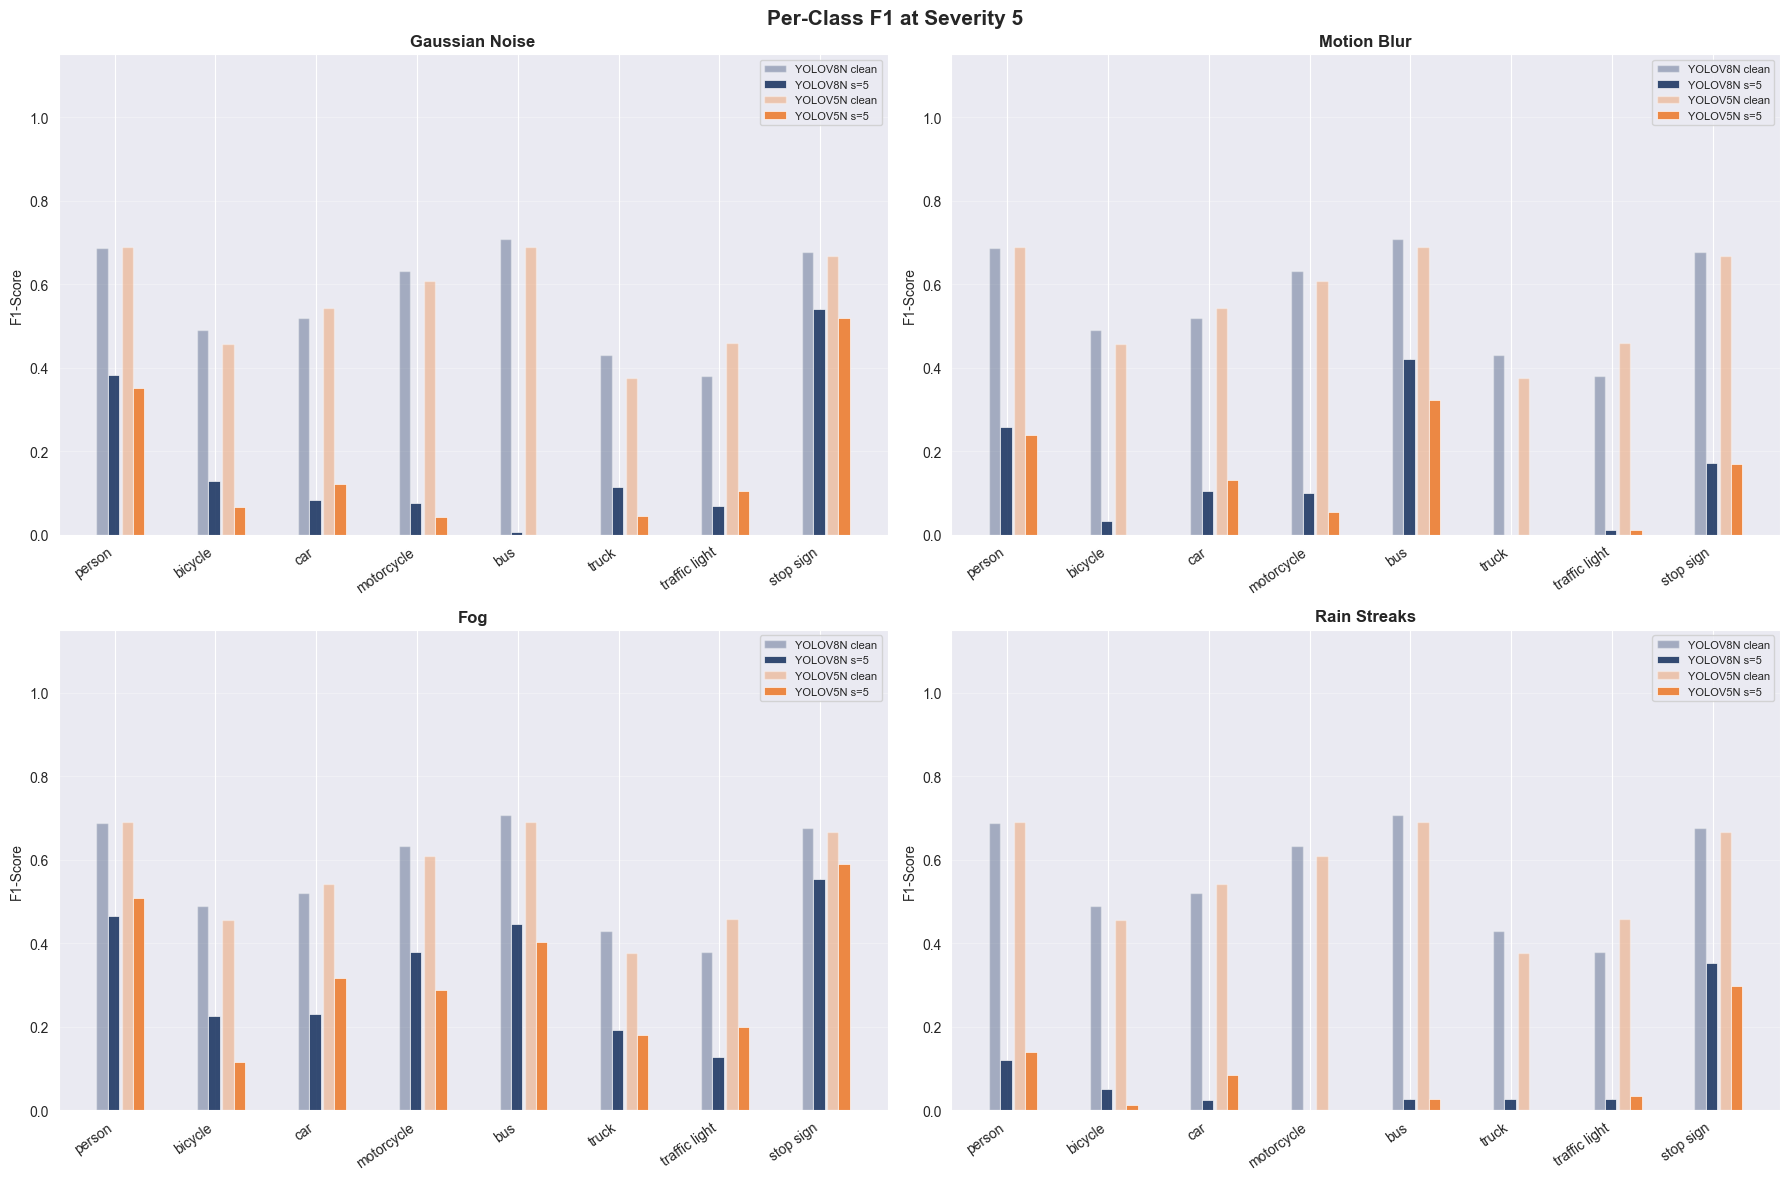

In [11]:
# ── 8. Per-Class F1 at Severity 5 ────────────────────────────────────────────
CLASS_NAMES = ['person','bicycle','car','motorcycle','bus','truck','traffic_light','stop_sign']
class_cols  = [f'f1_{c}' for c in CLASS_NAMES]

# Only plot if per-class columns exist
if class_cols[0] in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Per-Class F1 at Severity 5', fontsize=15, fontweight='bold')

    for ax, noise_key in zip(axes.flatten(), NOISE_ORDER):
        sub_s5    = df[(df['noise'] == noise_key) & (df['severity'] == 5)]
        clean_rows = df[df['noise'] == 'clean']
        x     = np.arange(len(CLASS_NAMES))
        width = 0.25

        for i, model_name in enumerate(['yolov8n', 'yolov5n']):
            clean_vals = clean_rows[clean_rows['model'] == model_name][class_cols].values
            noisy_vals = sub_s5[sub_s5['model'] == model_name][class_cols].values
            if not len(clean_vals) or not len(noisy_vals): continue

            offset = (i - 0.5) * width
            ax.bar(x + offset,               clean_vals[0], width*0.45,
                   color=COLORS[model_name], alpha=0.35, label=f'{model_name.upper()} clean')
            ax.bar(x + offset + width*0.45,  noisy_vals[0], width*0.45,
                   color=COLORS[model_name], alpha=0.9,  label=f'{model_name.upper()} s=5',
                   edgecolor='white', linewidth=0.5)

        ax.set_title(NOISE_LABELS[noise_key], fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([c.replace('_',' ') for c in CLASS_NAMES], rotation=35, ha='right')
        ax.set_ylim(0, 1.15)
        ax.set_ylabel('F1-Score')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR + r'\fig5_per_class_f1.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Per-class columns not found — skipping this plot.')

## 9. Hypothesis Validation Table

In [12]:
# ── 9. Hypothesis Validation ──────────────────────────────────────────────────
print('HYPOTHESIS VALIDATION')

# H1 — monotonic decrease with severity
h1 = []
for m in ['yolov8n','yolov5n']:
    for n in NOISE_ORDER:
        f1s = df[(df['model']==m) & (df['noise']==n)].sort_values('severity')['f1'].tolist()
        h1.append(all(f1s[i] >= f1s[i+1] for i in range(len(f1s)-1)))
print(f'H1 Monotonic decrease    : {"Yes" if sum(h1)/len(h1)>=0.75 else "No"}  ({sum(h1)}/{len(h1)} conditions)')

# H2 — blur/fog worse than gaussian at s=3
h2 = []
for m in ['yolov8n','yolov5n']:
    g = df[(df['model']==m) & (df['noise']=='gaussian')    & (df['severity']==3)]['rpd'].values[0]
    b = df[(df['model']==m) & (df['noise']=='motion_blur') & (df['severity']==3)]['rpd'].values[0]
    f = df[(df['model']==m) & (df['noise']=='fog')         & (df['severity']==3)]['rpd'].values[0]
    h2 += [b > g, f > g]
print(f'H2 Blur/Fog > Gaussian   : {"Yes" if all(h2) else "No"}')

# H3 — YOLOv8n more robust
rpd_v8 = df[(df['model']=='yolov8n') & df['noise'].isin(NOISE_ORDER)]['rpd'].mean()
rpd_v5 = df[(df['model']=='yolov5n') & df['noise'].isin(NOISE_ORDER)]['rpd'].mean()
print(f'H3 YOLOv8n more robust   : {"Yes" if rpd_v8 < rpd_v5 else "No"}  (v8={rpd_v8:.3f}  v5={rpd_v5:.3f})')


# Final summary
print(f'\nMost robust model  : {"YOLOv8n" if rpd_v8 < rpd_v5 else "YOLOv5n"}')
worst_noise = noisy.groupby('noise')['rpd'].mean().idxmax()
print(f'Most harmful noise : {NOISE_LABELS[worst_noise]}')

HYPOTHESIS VALIDATION
H1 Monotonic decrease    : Yes  (6/8 conditions)
H2 Blur/Fog > Gaussian   : Yes
H3 YOLOv8n more robust   : No  (v8=0.352  v5=0.328)

Most robust model  : YOLOv5n
Most harmful noise : Motion Blur


## 10. Full Summary Table (Paper-Ready)

In [13]:
    # ── 10. Save Full Summary CSV ─────────────────────────────────────────────────
summary = noisy.pivot_table(index=['noise','severity'], columns='model',
                             values=['f1','rpd']).round(4)
summary.columns = [f'{m}_{metric}' for metric, m in summary.columns]
summary = summary.reset_index()
summary['noise'] = summary['noise'].map(NOISE_LABELS)
summary.to_csv(RESULTS_DIR + r'\full_summary.csv', index=False)
print('Saved → results/full_summary.csv Yes')
print()
print(summary.to_string(index=False))

Saved → results/full_summary.csv Yes

         noise  severity  yolov5n_f1  yolov8n_f1  yolov5n_rpd  yolov8n_rpd
           Fog         1      0.4603      0.4075       0.2909       0.3683
           Fog         3      0.4606      0.4101       0.2904       0.3643
           Fog         5      0.4544      0.4131       0.3000       0.3596
Gaussian Noise         1      0.6336      0.6252       0.0239       0.0308
Gaussian Noise         3      0.5263      0.5110       0.1892       0.2079
Gaussian Noise         5      0.2915      0.3157       0.5509       0.5106
   Motion Blur         1      0.6033      0.5910       0.0706       0.0839
   Motion Blur         3      0.3791      0.3686       0.4160       0.4286
   Motion Blur         5      0.2060      0.2199       0.6826       0.6591
  Rain Streaks         1      0.6250      0.6112       0.0371       0.0525
  Rain Streaks         3      0.4757      0.4403       0.2671       0.3175
  Rain Streaks         5      0.1183      0.0988       0.8177 